# Sequence Classification: Latent-Space Differential

This notebook demonstrates a neural network classifier that predicts amino acids using a **latent-space differential** approach.

## Task Overview
- **Input**: Two spectra (dipeptide XY, amino acid X)
- **Process**: Encode each spectrum separately → compute difference in latent space
- **Output**: Predict the target amino acid Y (6 classes)

## Architecture
```
Spectrum_XY  →  Shared Encoder  →  z_XY  \
                                          →  z_diff = z_XY - z_X  →  Classifier  →  Y
Spectrum_X   →  Shared Encoder  →  z_X   /
```

## Key Difference from Other Approaches
- **Two-Channel (v1)**: Concatenates `[XY, X]` → model learns relationship
- **Differential (v2)**: Computes `XY - X` in input space → 1-channel input
- **Latent Differential (v3)**: Encodes separately → computes difference in latent space

## Motivation
Computing the difference in a learned latent space may capture more meaningful spectral features than raw subtraction, while still explicitly modeling the "added" amino acid contribution.

## Imports and Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

Using device: cuda


## Constants and Mappings

In [2]:
# Target amino acid classes (6 classes)
AMINO_ACID_CODES = ['A', 'D', 'F', 'G', 'R', 'S']
CODE_TO_IDX = {code: idx for idx, code in enumerate(AMINO_ACID_CODES)}
IDX_TO_CODE = {idx: code for code, idx in CODE_TO_IDX.items()}

# Full names for display
CODE_TO_NAME = {
    'A': 'Alanine',
    'D': 'Aspartic acid',
    'F': 'Phenylalanine',
    'G': 'Glycine',
    'R': 'Arginine',
    'S': 'Serine'
}

# Mapping from single-letter code to folder name in aminoacids directory
AMINOACID_FOLDER_MAPPING = {
    'A': 'L-Alanine',
    'D': 'L-Aspartic acid',
    'F': 'L-Phenylalanine',
    'G': 'Glycine',
    'R': 'L-Arginine',
    'S': 'L-Serine'
}

# Data loading parameters
MIN_SPECTRA = 5  # Minimum spectra to include (will be upsampled to TARGET_SPECTRA)
TARGET_SPECTRA = 200  # Exact number of spectra to load per case

print(f'Target classes: {AMINO_ACID_CODES}')
print(f'Class mapping: {CODE_TO_IDX}')
print(f'Target spectra per case: {TARGET_SPECTRA}')

Target classes: ['A', 'D', 'F', 'G', 'R', 'S']
Class mapping: {'A': 0, 'D': 1, 'F': 2, 'G': 3, 'R': 4, 'S': 5}
Target spectra per case: 200


## Data Loading

In [3]:
# Data directories
dipeptide_dir = Path('./data/processed/dipeptides')
aminoacid_dir = Path('./data/processed/aminoacids')

def resample_to_target(spectra, target_count, random_state=42):
    """Resample spectra to exactly target_count samples.
    
    If spectra > target_count: downsample without replacement
    If spectra < target_count: upsample with replacement
    """
    np.random.seed(random_state)
    n_samples = len(spectra)
    
    if n_samples == target_count:
        return spectra.copy()
    elif n_samples > target_count:
        indices = np.random.choice(n_samples, target_count, replace=False)
    else:
        indices = np.random.choice(n_samples, target_count, replace=True)
    
    return spectra[indices]

# Load dipeptide data
dipeptide_data = {}
print(f'Loading dipeptide data (resampling to {TARGET_SPECTRA} spectra each)...')
for folder in sorted(dipeptide_dir.iterdir()):
    if folder.is_dir():
        clean_data_path = folder / 'clean_data.npz'
        if clean_data_path.exists():
            data = np.load(clean_data_path, allow_pickle=True)
            intensities = data['intensities']
            n_spectra = intensities.shape[0]
            if n_spectra >= MIN_SPECTRA:
                resampled = resample_to_target(intensities, TARGET_SPECTRA, 
                                                random_state=42 + len(dipeptide_data))
                dipeptide_data[folder.name] = resampled
                action = "↓" if n_spectra > TARGET_SPECTRA else "↑" if n_spectra < TARGET_SPECTRA else "="
                print(f'  {folder.name}: {n_spectra} → {TARGET_SPECTRA} spectra ({action})')

print(f'\nLoaded {len(dipeptide_data)} dipeptides with {TARGET_SPECTRA} spectra each')

Loading dipeptide data (resampling to 200 spectra each)...
  AD: 397 → 200 spectra (↓)
  AF: 1246 → 200 spectra (↓)
  AG: 1446 → 200 spectra (↓)
  AR: 188 → 200 spectra (↑)
  AS: 31 → 200 spectra (↑)
  DA: 318 → 200 spectra (↓)
  DF: 1372 → 200 spectra (↓)
  DG: 483 → 200 spectra (↓)
  DR: 586 → 200 spectra (↓)
  DS: 141 → 200 spectra (↑)
  FA: 15 → 200 spectra (↑)
  FD: 226 → 200 spectra (↓)
  FG: 1432 → 200 spectra (↓)
  FR: 347 → 200 spectra (↓)
  FS: 570 → 200 spectra (↓)
  GA: 58 → 200 spectra (↑)
  GD: 732 → 200 spectra (↓)
  GF: 1476 → 200 spectra (↓)
  GR: 859 → 200 spectra (↓)
  RA: 209 → 200 spectra (↓)
  RD: 446 → 200 spectra (↓)
  RF: 196 → 200 spectra (↑)
  RG: 439 → 200 spectra (↓)
  RS: 102 → 200 spectra (↑)
  SA: 181 → 200 spectra (↑)
  SD: 14 → 200 spectra (↑)
  SF: 190 → 200 spectra (↑)
  SG: 44 → 200 spectra (↑)
  SR: 205 → 200 spectra (↓)

Loaded 29 dipeptides with 200 spectra each


In [4]:
# Load amino acid data
aminoacid_data = {}
print(f'Loading amino acid data (resampling to {TARGET_SPECTRA} spectra each)...')
for code, folder_name in AMINOACID_FOLDER_MAPPING.items():
    folder_path = aminoacid_dir / folder_name
    clean_data_path = folder_path / 'clean_data.npz'
    if clean_data_path.exists():
        data = np.load(clean_data_path, allow_pickle=True)
        intensities = data['intensities']
        n_spectra = intensities.shape[0]
        if n_spectra >= MIN_SPECTRA:
            resampled = resample_to_target(intensities, TARGET_SPECTRA, 
                                            random_state=100 + len(aminoacid_data))
            aminoacid_data[code] = resampled
            action = "↓" if n_spectra > TARGET_SPECTRA else "↑" if n_spectra < TARGET_SPECTRA else "="
            print(f'  {code} ({folder_name}): {n_spectra} → {TARGET_SPECTRA} spectra ({action})')

print(f'\nLoaded {len(aminoacid_data)} amino acids with {TARGET_SPECTRA} spectra each')

Loading amino acid data (resampling to 200 spectra each)...
  A (L-Alanine): 2414 → 200 spectra (↓)
  D (L-Aspartic acid): 1003 → 200 spectra (↓)
  F (L-Phenylalanine): 2338 → 200 spectra (↓)
  G (Glycine): 2064 → 200 spectra (↓)
  R (L-Arginine): 1533 → 200 spectra (↓)
  S (L-Serine): 2205 → 200 spectra (↓)

Loaded 6 amino acids with 200 spectra each


## Dataset Class

In [5]:
class LatentDiffDataset(Dataset):
    """Dataset for latent-space differential classification.
    
    Dipeptide pairs: (dipeptide XY, amino acid X) → predict Y
    """
    
    def __init__(self, dipeptide_data, aminoacid_data, seq_length=1023,
                 samples_per_pair=None, max_samples_per_class=None):
        self.pairs = []
        self.pair_info = []
        self.seq_length = seq_length
        
        class_pairs = {i: [] for i in range(len(AMINO_ACID_CODES))}
        
        print("Adding dipeptide-aminoacid pairs...")
        for dipeptide_name, dipeptide_spectra in dipeptide_data.items():
            first_aa = dipeptide_name[0]
            second_aa = dipeptide_name[1]
            
            if first_aa not in aminoacid_data:
                continue
            if second_aa not in CODE_TO_IDX:
                continue
            
            aa_spectra = aminoacid_data[first_aa]
            label = CODE_TO_IDX[second_aa]
            
            n_dipeptide = len(dipeptide_spectra)
            n_aa = len(aa_spectra)
            n_pairs = min(n_dipeptide, n_aa)
            if samples_per_pair is not None:
                n_pairs = min(n_pairs, samples_per_pair)
            
            dip_indices = np.random.choice(n_dipeptide, n_pairs, replace=False)
            aa_indices = np.random.choice(n_aa, n_pairs, replace=False)
            
            for di, ai in zip(dip_indices, aa_indices):
                class_pairs[label].append((
                    dipeptide_spectra[di],
                    aa_spectra[ai],
                    label,
                    ('dipeptide', dipeptide_name, first_aa, second_aa)
                ))
        
        print("\nBalancing classes...")
        for label, pairs in class_pairs.items():
            if len(pairs) == 0:
                continue
            np.random.shuffle(pairs)
            if max_samples_per_class is not None and len(pairs) > max_samples_per_class:
                pairs = pairs[:max_samples_per_class]
            for dip, aa, lbl, info in pairs:
                self.pairs.append((dip, aa, lbl))
                self.pair_info.append(info)
        
        combined = list(zip(self.pairs, self.pair_info))
        np.random.shuffle(combined)
        self.pairs, self.pair_info = zip(*combined) if combined else ([], [])
        self.pairs = list(self.pairs)
        self.pair_info = list(self.pair_info)
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        dip, aa, label = self.pairs[idx]
        return (
            torch.tensor(dip, dtype=torch.float32),
            torch.tensor(aa, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long)
        )
    
    def get_labels(self):
        return [p[2] for p in self.pairs]
    
    def get_class_distribution(self):
        labels = self.get_labels()
        unique, counts = np.unique(labels, return_counts=True)
        return {IDX_TO_CODE[u]: c for u, c in zip(unique, counts)}

In [6]:
# Create dataset
print('Creating latent-diff dataset (dipeptide pairs only)...\n')
dataset = LatentDiffDataset(
    dipeptide_data, 
    aminoacid_data,
    seq_length=1023,
    samples_per_pair=None,
    max_samples_per_class=1000,
)
print(f'\nTotal samples: {len(dataset)}')

class_dist = dataset.get_class_distribution()
print('\nClass distribution (balanced):')
for code, count in sorted(class_dist.items()):
    print(f'  {code} ({CODE_TO_NAME[code]}): {count} samples')

Creating latent-diff dataset (dipeptide pairs only)...

Adding dipeptide-aminoacid pairs...

Balancing classes...

Total samples: 5800

Class distribution (balanced):
  A (Alanine): 1000 samples
  D (Aspartic acid): 1000 samples
  F (Phenylalanine): 1000 samples
  G (Glycine): 1000 samples
  R (Arginine): 1000 samples
  S (Serine): 800 samples


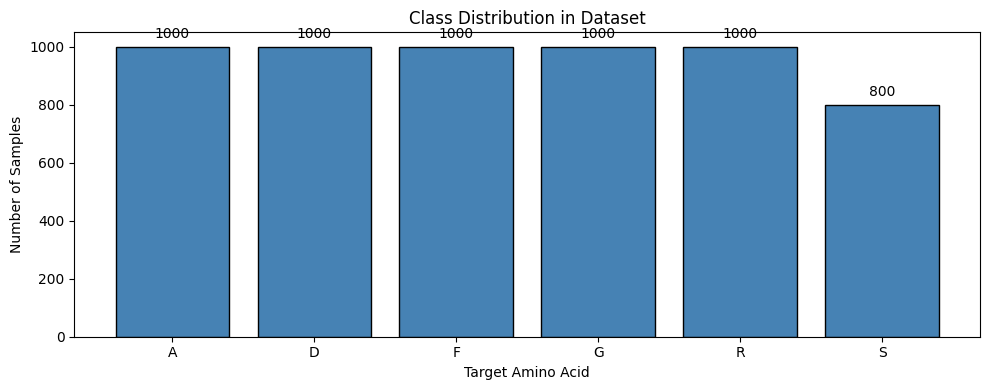

In [7]:
# Visualize class distribution
codes = list(class_dist.keys())
counts = [class_dist[c] for c in codes]

plt.figure(figsize=(10, 4))
plt.bar(codes, counts, color='steelblue', edgecolor='black')
plt.xlabel('Target Amino Acid')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Dataset')
for i, (c, cnt) in enumerate(zip(codes, counts)):
    plt.text(i, cnt + 20, str(cnt), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Train/Validation Split and Data Augmentation

In [8]:
# Stratified train/val split (80/20)
labels = dataset.get_labels()
indices = list(range(len(dataset)))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(f'Training samples: {len(train_indices)}')
print(f'Validation samples: {len(val_indices)}')

Training samples: 4640
Validation samples: 1160


In [9]:
# Data Augmentation (reduced for better generalization)
class SpectraAugmentation:
    def __init__(self, noise_std=0.02, scale_range=(0.98, 1.02), shift_range=(-0.02, 0.02)):
        self.noise_std = noise_std
        self.scale_range = scale_range
        self.shift_range = shift_range
    
    def __call__(self, spectrum):
        spectrum = spectrum.copy()
        if self.noise_std > 0:
            noise = np.random.normal(0, self.noise_std, spectrum.shape)
            spectrum = spectrum + noise
        if self.scale_range is not None:
            scale = np.random.uniform(self.scale_range[0], self.scale_range[1])
            spectrum = spectrum * scale
        if self.shift_range is not None:
            shift = np.random.uniform(self.shift_range[0], self.shift_range[1])
            spectrum = spectrum + shift
        return spectrum.astype(np.float32)


class AugmentedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    
    def __len__(self):
        return len(self.subset)
    
    def __getitem__(self, idx):
        dip, aa, label = self.subset[idx]
        if self.transform:
            dip_np = dip.numpy() if isinstance(dip, torch.Tensor) else dip
            aa_np = aa.numpy() if isinstance(aa, torch.Tensor) else aa
            dip = torch.tensor(self.transform(dip_np), dtype=torch.float32)
            aa = torch.tensor(self.transform(aa_np), dtype=torch.float32)
        return dip, aa, label


# Create augmentation with reduced intensity
augmentation = SpectraAugmentation(
    noise_std=0.02,
    scale_range=(0.98, 1.02),
    shift_range=(-0.02, 0.02)
)

print("Data augmentation configured (reduced):")
print(f"  - Gaussian noise std: {augmentation.noise_std}")
print(f"  - Intensity scale range: {augmentation.scale_range}")
print(f"  - Baseline shift range: {augmentation.shift_range}")

Data augmentation configured (reduced):
  - Gaussian noise std: 0.02
  - Intensity scale range: (0.98, 1.02)
  - Baseline shift range: (-0.02, 0.02)


In [10]:
# Create data loaders
batch_size = 32

train_subset = Subset(dataset, train_indices)
val_subset = Subset(dataset, val_indices)

train_dataset_aug = AugmentedDataset(train_subset, transform=augmentation)

train_loader = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

print(f'Training samples (with augmentation): {len(train_dataset_aug):,}')
print(f'Validation samples (no augmentation): {len(val_subset):,}')
print(f'\nBatch size: {batch_size}')
print(f'Training batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')

Training samples (with augmentation): 4,640
Validation samples (no augmentation): 1,160

Batch size: 32
Training batches: 145
Validation batches: 37


## Model Architecture (Latent-Space Differential)

The model has three main components:
1. **Shared Encoder**: Encodes each spectrum into a latent representation
2. **Latent Difference**: Computes `z_diff = z_dipeptide - z_aminoacid`
3. **Classifier**: Classifies based on the latent difference

In [11]:
class LatentDiffClassifier(nn.Module):
    """Classifier using latent-space differential.
    
    Architecture:
        Spectrum_XY → Encoder → z_XY \
                                      → z_diff = z_XY - z_X → Classifier → Y
        Spectrum_X  → Encoder → z_X  /
    
    The encoder is shared between both inputs (Siamese-like).
    """
    
    def __init__(self, seq_length=1023, d_model=64, latent_dim=128, num_classes=6, dropout=0.3):
        super().__init__()
        
        self.seq_length = seq_length
        self.d_model = d_model
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        
        # Shared encoder: spectrum → latent representation
        self.encoder = nn.Sequential(
            # First conv block
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2),  # seq_len / 2
            
            # Second conv block
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2),  # seq_len / 4
            
            # Third conv block
            nn.Conv1d(32, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.AdaptiveAvgPool1d(16),  # Fixed output size
        )
        
        # Project to latent space
        self.to_latent = nn.Sequential(
            nn.Flatten(),
            nn.Linear(d_model * 16, latent_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        # Classifier: latent difference → class
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, latent_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout + 0.1),
            nn.Linear(latent_dim // 2, num_classes),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def encode(self, spectrum):
        """Encode a spectrum to latent space.
        
        Args:
            spectrum: (batch, seq_len)
        
        Returns:
            Latent representation (batch, latent_dim)
        """
        x = spectrum.unsqueeze(1)  # (batch, 1, seq_len)
        x = self.encoder(x)  # (batch, d_model, 16)
        z = self.to_latent(x)  # (batch, latent_dim)
        return z
    
    def forward(self, spectrum_dipeptide, spectrum_aminoacid):
        """Forward pass.
        
        Args:
            spectrum_dipeptide: Dipeptide spectrum (batch, seq_len)
            spectrum_aminoacid: Amino acid spectrum (batch, seq_len)
        
        Returns:
            Logits of shape (batch, num_classes)
        """
        # Encode both spectra with shared encoder
        z_dip = self.encode(spectrum_dipeptide)  # (batch, latent_dim)
        z_aa = self.encode(spectrum_aminoacid)   # (batch, latent_dim)
        
        # Compute difference in latent space
        z_diff = z_dip - z_aa  # (batch, latent_dim)
        
        # Classify based on latent difference
        logits = self.classifier(z_diff)  # (batch, num_classes)
        
        return logits
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [12]:
# Create model
model = LatentDiffClassifier(
    seq_length=1023,
    d_model=64,
    latent_dim=128,
    num_classes=len(AMINO_ACID_CODES),
    dropout=0.3
).to(device)

print(f'Model parameters: {model.count_parameters():,}')
print(f'\nModel architecture:')
print(model)

Model parameters: 148,998

Model architecture:
LatentDiffClassifier(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): GELU(approximate='none')
    (13): Dropout(p=0.3, inplace=False)
    (14): AdaptiveAvgPool1d(output_size=16

In [13]:
# Verify encoder output shapes
with torch.no_grad():
    dummy_spectrum = torch.randn(2, 1023).to(device)
    z = model.encode(dummy_spectrum)
    print(f'Input shape: {dummy_spectrum.shape}')
    print(f'Latent shape: {z.shape}')
    
    dummy_dip = torch.randn(2, 1023).to(device)
    dummy_aa = torch.randn(2, 1023).to(device)
    logits = model(dummy_dip, dummy_aa)
    print(f'Output logits shape: {logits.shape}')

Input shape: torch.Size([2, 1023])
Latent shape: torch.Size([2, 128])
Output logits shape: torch.Size([2, 6])


## Training

In [14]:
def train_model(model, train_loader, val_loader, epochs=100, lr=0.001, patience=20,
                resume_checkpoint=None):
    """Train the model with early stopping and optional resume."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_loss = float('inf')
    best_val_acc = 0
    epochs_without_improvement = 0
    start_epoch = 0
    
    if resume_checkpoint and Path(resume_checkpoint).exists():
        checkpoint = torch.load(resume_checkpoint)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['val_loss']
        best_val_acc = checkpoint['val_acc']
        print(f'Resuming from epoch {start_epoch}')
        print(f'Previous best: val_loss={best_val_loss:.4f}, val_acc={best_val_acc:.2f}%\n')
    
    Path('checkpoints').mkdir(exist_ok=True)
    
    for epoch in range(start_epoch, epochs):
        # Training
        model.train()
        train_loss = 0
        for dip, aa, labels in train_loader:
            dip, aa, labels = dip.to(device), aa.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(dip, aa)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for dip, aa, labels in val_loader:
                dip, aa, labels = dip.to(device), aa.to(device), labels.to(device)
                outputs = model(dip, aa)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = 100. * correct / total
        
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            epochs_without_improvement = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
            }, 'checkpoints/sequence_classifier_latent_best.pt')
        else:
            epochs_without_improvement += 1
        
        if (epoch + 1) % 10 == 0 or epoch == start_epoch:
            print(f'Epoch {epoch+1:3d}/{epochs}: '
                  f'Train Loss={train_loss:.4f}, '
                  f'Val Loss={val_loss:.4f}, '
                  f'Val Acc={val_acc:.2f}%, '
                  f'LR={current_lr:.2e}')
        
        if epochs_without_improvement >= patience:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break
    
    print(f'\nBest validation loss: {best_val_loss:.4f}')
    print(f'Best validation accuracy: {best_val_acc:.2f}%')
    
    return history

In [15]:
# Train the model
print('Starting training...')
print('Model: LatentDiffClassifier (latent-space differential)\n')

history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.0001,
    patience=100,
    resume_checkpoint=None
)

Starting training...
Model: LatentDiffClassifier (latent-space differential)

Epoch   1/50: Train Loss=1.5312, Val Loss=1.3884, Val Acc=61.29%, LR=1.00e-04
Epoch  10/50: Train Loss=0.3205, Val Loss=0.3242, Val Acc=94.57%, LR=1.00e-04
Epoch  20/50: Train Loss=0.1453, Val Loss=0.1384, Val Acc=98.62%, LR=1.00e-04
Epoch  30/50: Train Loss=0.0812, Val Loss=0.0700, Val Acc=99.40%, LR=1.00e-04
Epoch  40/50: Train Loss=0.0579, Val Loss=0.0450, Val Acc=99.40%, LR=1.00e-04
Epoch  50/50: Train Loss=0.0389, Val Loss=0.0345, Val Acc=99.57%, LR=1.00e-04

Best validation loss: 0.0345
Best validation accuracy: 99.57%


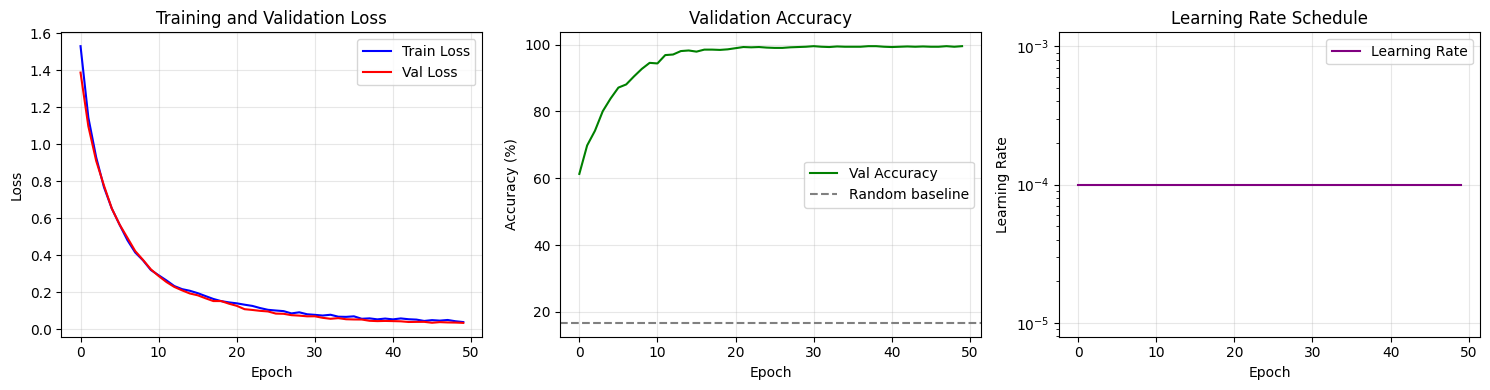

In [16]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[1].axhline(y=100/len(AMINO_ACID_CODES), color='gray', linestyle='--', label='Random baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['lr'], label='Learning Rate', color='purple')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluation

In [17]:
# Load best model
checkpoint = torch.load('checkpoints/sequence_classifier_latent_best.pt')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Best validation accuracy: {checkpoint['val_acc']:.2f}%")

Loaded best model from epoch 50
Best validation accuracy: 99.57%


In [18]:
# Evaluate on validation set
model.eval()
all_predictions = []
all_labels = []
all_probs = []

with torch.no_grad():
    for dip, aa, labels in val_loader:
        dip, aa = dip.to(device), aa.to(device)
        outputs = model(dip, aa)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

accuracy = 100.0 * np.mean(all_predictions == all_labels)
print(f'Validation Accuracy: {accuracy:.2f}%')
print(f'Random baseline: {100/len(AMINO_ACID_CODES):.2f}%')

Validation Accuracy: 99.57%
Random baseline: 16.67%


In [19]:
# Classification report
target_names = [f'{code} ({CODE_TO_NAME[code]})' for code in AMINO_ACID_CODES]
print('\nClassification Report:')
print('=' * 60)
print(classification_report(all_labels, all_predictions, target_names=target_names, digits=3))


Classification Report:
                   precision    recall  f1-score   support

      A (Alanine)      0.990     1.000     0.995       200
D (Aspartic acid)      0.995     0.990     0.992       200
F (Phenylalanine)      0.995     1.000     0.998       200
      G (Glycine)      1.000     0.995     0.997       200
     R (Arginine)      0.995     0.990     0.992       200
       S (Serine)      1.000     1.000     1.000       160

         accuracy                          0.996      1160
        macro avg      0.996     0.996     0.996      1160
     weighted avg      0.996     0.996     0.996      1160



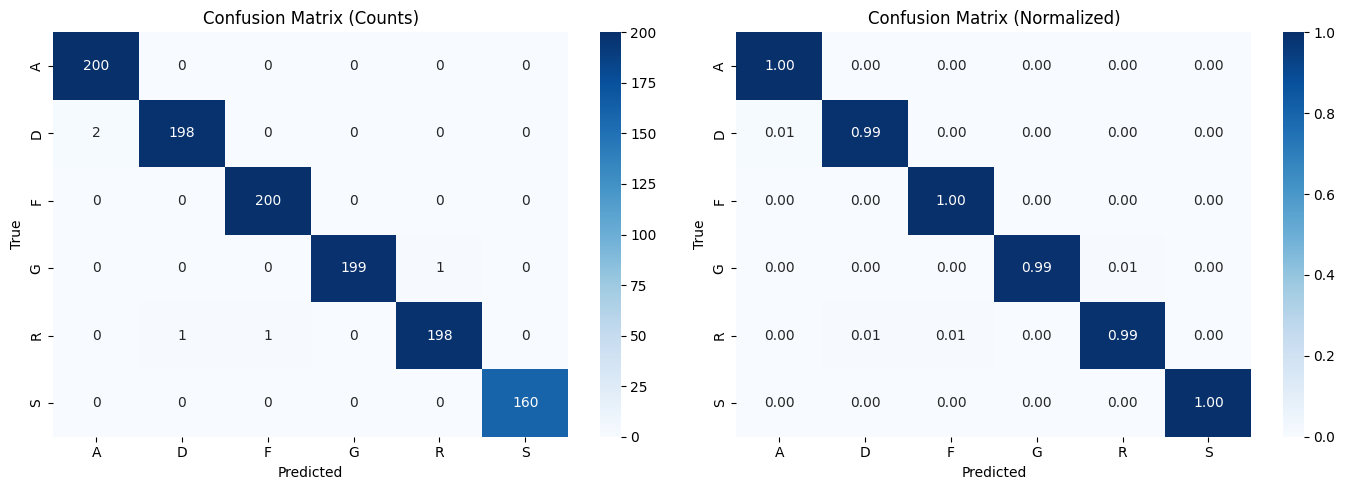

In [20]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=AMINO_ACID_CODES, yticklabels=AMINO_ACID_CODES)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (Counts)')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=AMINO_ACID_CODES, yticklabels=AMINO_ACID_CODES)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.show()

In [21]:
# Per-class accuracy
print('\nPer-class accuracy:')
for i, code in enumerate(AMINO_ACID_CODES):
    class_mask = all_labels == i
    if class_mask.sum() > 0:
        class_acc = 100.0 * (all_predictions[class_mask] == i).mean()
        print(f'  {code} ({CODE_TO_NAME[code]}): {class_acc:.2f}% ({class_mask.sum()} samples)')


Per-class accuracy:
  A (Alanine): 100.00% (200 samples)
  D (Aspartic acid): 99.00% (200 samples)
  F (Phenylalanine): 100.00% (200 samples)
  G (Glycine): 99.50% (200 samples)
  R (Arginine): 99.00% (200 samples)
  S (Serine): 100.00% (160 samples)


## Visualize Latent Space

In [22]:
# Extract latent representations for visualization
from sklearn.decomposition import PCA

model.eval()
latent_diffs = []
latent_dips = []
latent_aas = []
labels_list = []

with torch.no_grad():
    for dip, aa, labels in val_loader:
        dip, aa = dip.to(device), aa.to(device)
        
        z_dip = model.encode(dip)
        z_aa = model.encode(aa)
        z_diff = z_dip - z_aa
        
        latent_diffs.extend(z_diff.cpu().numpy())
        latent_dips.extend(z_dip.cpu().numpy())
        latent_aas.extend(z_aa.cpu().numpy())
        labels_list.extend(labels.numpy())

latent_diffs = np.array(latent_diffs)
latent_dips = np.array(latent_dips)
latent_aas = np.array(latent_aas)
labels_array = np.array(labels_list)

print(f'Latent diff shape: {latent_diffs.shape}')
print(f'Labels shape: {labels_array.shape}')

Latent diff shape: (1160, 128)
Labels shape: (1160,)


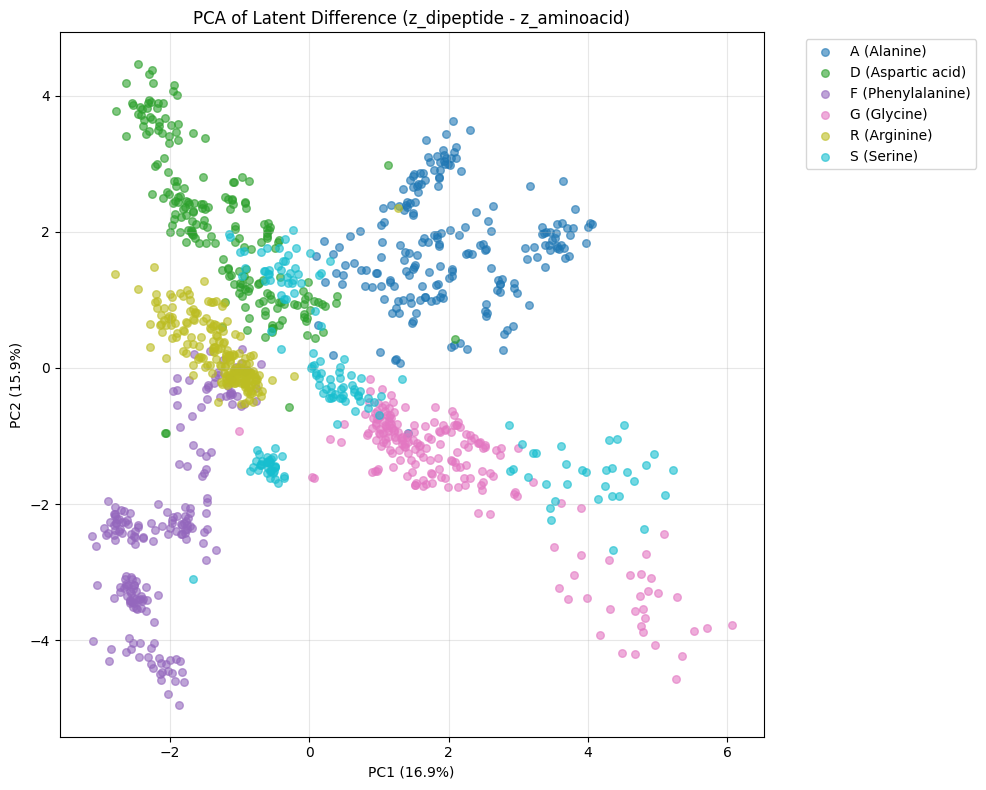

In [23]:
# PCA visualization of latent difference
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_diffs)

plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(AMINO_ACID_CODES)))

for i, code in enumerate(AMINO_ACID_CODES):
    mask = labels_array == i
    if mask.sum() > 0:
        plt.scatter(latent_2d[mask, 0], latent_2d[mask, 1], 
                   c=[colors[i]], label=f'{code} ({CODE_TO_NAME[code]})', alpha=0.6, s=30)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA of Latent Difference (z_dipeptide - z_aminoacid)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated a **latent-space differential** classifier for amino acid classification.

### Architecture
```
Spectrum_XY  →  Shared Encoder  →  z_XY  \
                                          →  z_diff = z_XY - z_X  →  Classifier  →  Y
Spectrum_X   →  Shared Encoder  →  z_X   /
```

### Key Features
1. **Shared encoder**: Same network encodes both spectra (Siamese-like)
2. **Latent difference**: Computes difference in learned feature space
3. **Lightweight classifier**: Simple MLP on latent difference

### Comparison with Other Approaches
| Approach | Input Processing | When Difference Computed |
|----------|------------------|-------------------------|
| Two-Channel (v1) | Concatenate [XY, X] | Never (model learns) |
| Differential (v2) | XY - X | Input space (before encoder) |
| **Latent Diff (v3)** | Encode separately | Latent space (after encoder) |

### Advantages of Latent-Space Differential
- Encoder can learn meaningful features before subtraction
- More robust to noise (features may be more invariant)
- Shared encoder ensures consistent representation space

## Evaluation on Tripeptide-Dipeptide Data

In [24]:
# Load tripeptide data
tripeptide_dir = Path('./data/processed/tripeptides')

tripeptide_data = {}
print('Loading tripeptide data...')
for folder in sorted(tripeptide_dir.iterdir()):
    if folder.is_dir():
        clean_data_path = folder / 'clean_data.npz'
        if clean_data_path.exists():
            data = np.load(clean_data_path, allow_pickle=True)
            intensities = data['intensities']
            n_spectra = intensities.shape[0]
            if n_spectra >= MIN_SPECTRA:
                tripeptide_data[folder.name] = intensities
                print(f'  {folder.name}: {n_spectra} spectra')

print(f'\nLoaded {len(tripeptide_data)} tripeptides')

Loading tripeptide data...
  AFG: 229 spectra
  AFR: 57 spectra
  AGF: 520 spectra
  ARS: 29 spectra
  ASF: 707 spectra
  DFA: 264 spectra
  DFS: 1301 spectra
  DGF: 80 spectra
  DRF: 147 spectra
  DSR: 276 spectra
  FAR: 401 spectra
  FDR: 250 spectra
  FGA: 293 spectra
  FGR: 161 spectra
  FGS: 838 spectra
  FRS: 652 spectra
  FSA: 660 spectra
  FSG: 35 spectra
  FSR: 340 spectra
  GAR: 189 spectra
  GDR: 1847 spectra
  GDS: 1519 spectra
  GRS: 139 spectra
  RAG: 267 spectra
  RAS: 179 spectra
  RFD: 211 spectra
  RSA: 9 spectra
  RSD: 89 spectra
  RSF: 82 spectra
  SDF: 103 spectra
  SGA: 34 spectra
  SGF: 272 spectra
  SRA: 1470 spectra

Loaded 33 tripeptides


In [25]:
# Create tripeptide-dipeptide evaluation dataset
class TripeptideDipeptideDataset(Dataset):
    def __init__(self, tripeptide_data, dipeptide_data, samples_per_pair=None):
        self.pairs = []
        self.pair_info = []
        
        print("Creating tripeptide-dipeptide pairs...")
        for tripeptide_name, tripeptide_spectra in tripeptide_data.items():
            xy = tripeptide_name[:2]
            z = tripeptide_name[2]
            
            if xy not in dipeptide_data:
                continue
            if z not in CODE_TO_IDX:
                continue
            
            dipeptide_spectra = dipeptide_data[xy]
            label = CODE_TO_IDX[z]
            
            n_tripeptide = len(tripeptide_spectra)
            n_dipeptide = len(dipeptide_spectra)
            n_pairs = min(n_tripeptide, n_dipeptide)
            if samples_per_pair is not None:
                n_pairs = min(n_pairs, samples_per_pair)
            
            tri_indices = np.random.choice(n_tripeptide, n_pairs, replace=False)
            dip_indices = np.random.choice(n_dipeptide, n_pairs, replace=False)
            
            for ti, di in zip(tri_indices, dip_indices):
                self.pairs.append((tripeptide_spectra[ti], dipeptide_spectra[di], label))
                self.pair_info.append(('tripeptide', tripeptide_name, xy, z))
            
            print(f'  {tripeptide_name} - {xy} → {z}: {n_pairs} pairs')
        
        print(f'\nTotal pairs: {len(self.pairs)}')
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        tri, dip, label = self.pairs[idx]
        return (
            torch.tensor(tri, dtype=torch.float32),
            torch.tensor(dip, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long)
        )
    
    def get_class_distribution(self):
        labels = [p[2] for p in self.pairs]
        unique, counts = np.unique(labels, return_counts=True)
        return {IDX_TO_CODE[u]: c for u, c in zip(unique, counts)}

tripeptide_eval_dataset = TripeptideDipeptideDataset(
    tripeptide_data,
    dipeptide_data,
    samples_per_pair=50
)

tri_class_dist = tripeptide_eval_dataset.get_class_distribution()
print('\nTripeptide evaluation class distribution:')
for code, count in sorted(tri_class_dist.items()):
    print(f'  {code} ({CODE_TO_NAME[code]}): {count} samples')

Creating tripeptide-dipeptide pairs...
  AFG - AF → G: 50 pairs
  AFR - AF → R: 50 pairs
  AGF - AG → F: 50 pairs
  ARS - AR → S: 29 pairs
  ASF - AS → F: 50 pairs
  DFA - DF → A: 50 pairs
  DFS - DF → S: 50 pairs
  DGF - DG → F: 50 pairs
  DRF - DR → F: 50 pairs
  DSR - DS → R: 50 pairs
  FAR - FA → R: 50 pairs
  FDR - FD → R: 50 pairs
  FGA - FG → A: 50 pairs
  FGR - FG → R: 50 pairs
  FGS - FG → S: 50 pairs
  FRS - FR → S: 50 pairs
  FSA - FS → A: 50 pairs
  FSG - FS → G: 35 pairs
  FSR - FS → R: 50 pairs
  GAR - GA → R: 50 pairs
  GDR - GD → R: 50 pairs
  GDS - GD → S: 50 pairs
  GRS - GR → S: 50 pairs
  RAG - RA → G: 50 pairs
  RAS - RA → S: 50 pairs
  RFD - RF → D: 50 pairs
  RSA - RS → A: 9 pairs
  RSD - RS → D: 50 pairs
  RSF - RS → F: 50 pairs
  SDF - SD → F: 50 pairs
  SGA - SG → A: 34 pairs
  SGF - SG → F: 50 pairs
  SRA - SR → A: 50 pairs

Total pairs: 1557

Tripeptide evaluation class distribution:
  A (Alanine): 243 samples
  D (Aspartic acid): 100 samples
  F (Phenylalan

In [26]:
# Evaluate on tripeptide-dipeptide pairs
tripeptide_loader = DataLoader(tripeptide_eval_dataset, batch_size=32, shuffle=False)

model.eval()
tri_predictions = []
tri_labels = []
tri_probs = []

with torch.no_grad():
    for tri, dip, labels in tripeptide_loader:
        tri, dip = tri.to(device), dip.to(device)
        outputs = model(tri, dip)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        tri_predictions.extend(predicted.cpu().numpy())
        tri_labels.extend(labels.numpy())
        tri_probs.extend(probs.cpu().numpy())

tri_predictions = np.array(tri_predictions)
tri_labels = np.array(tri_labels)
tri_probs = np.array(tri_probs)

tri_accuracy = 100.0 * np.mean(tri_predictions == tri_labels)
print(f'Tripeptide-Dipeptide Evaluation Accuracy: {tri_accuracy:.2f}%')
print(f'Random baseline: {100/len(AMINO_ACID_CODES):.2f}%')

Tripeptide-Dipeptide Evaluation Accuracy: 57.93%
Random baseline: 16.67%


In [27]:
# Tripeptide classification report
print('\nTripeptide-Dipeptide Classification Report:')
print('=' * 70)
tri_present_classes = sorted(set(tri_labels))
tri_target_names = [f'{IDX_TO_CODE[i]} ({CODE_TO_NAME[IDX_TO_CODE[i]]})' for i in tri_present_classes]
print(classification_report(
    tri_labels, 
    tri_predictions, 
    labels=tri_present_classes,
    target_names=tri_target_names, 
    digits=3,
    zero_division=0
))


Tripeptide-Dipeptide Classification Report:
                   precision    recall  f1-score   support

      A (Alanine)      0.807     0.189     0.307       243
D (Aspartic acid)      0.357     0.650     0.461       100
F (Phenylalanine)      0.791     0.994     0.881       350
      G (Glycine)      0.199     0.526     0.289       135
     R (Arginine)      0.855     0.765     0.807       400
       S (Serine)      0.405     0.201     0.268       329

         accuracy                          0.579      1557
        macro avg      0.569     0.554     0.502      1557
     weighted avg      0.649     0.579     0.565      1557



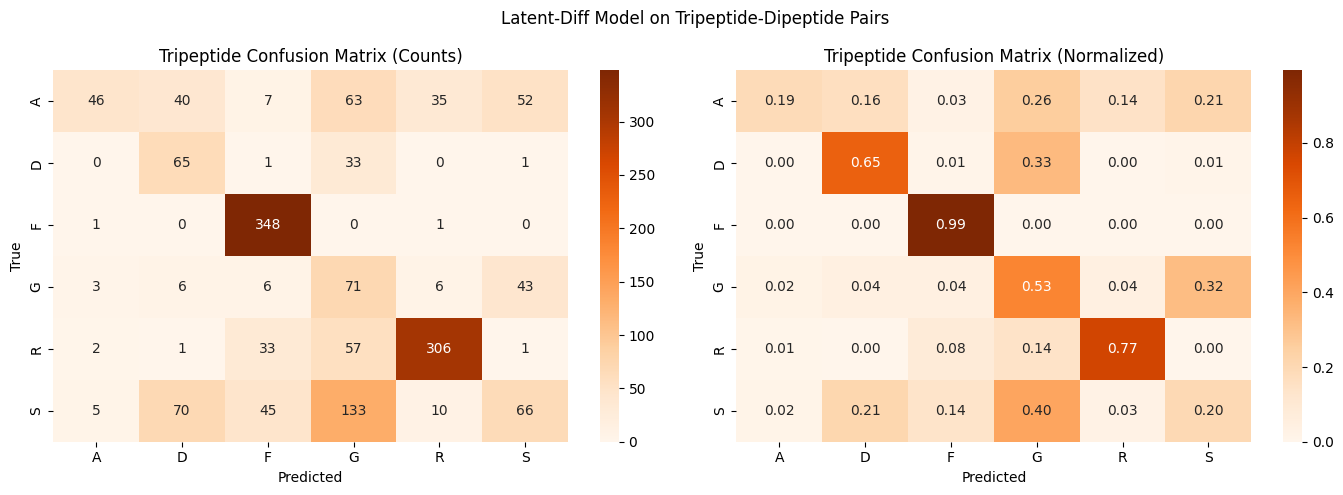

In [28]:
# Tripeptide confusion matrix
tri_cm = confusion_matrix(tri_labels, tri_predictions, labels=list(range(6)))
tri_cm_normalized = np.zeros_like(tri_cm, dtype=float)
for i in range(6):
    if tri_cm[i].sum() > 0:
        tri_cm_normalized[i] = tri_cm[i].astype('float') / tri_cm[i].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(tri_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=AMINO_ACID_CODES, yticklabels=AMINO_ACID_CODES)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Tripeptide Confusion Matrix (Counts)')

sns.heatmap(tri_cm_normalized, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1],
            xticklabels=AMINO_ACID_CODES, yticklabels=AMINO_ACID_CODES)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Tripeptide Confusion Matrix (Normalized)')

plt.suptitle('Latent-Diff Model on Tripeptide-Dipeptide Pairs', fontsize=12)
plt.tight_layout()
plt.show()

In [29]:
# Summary comparison
print('=' * 70)
print('EVALUATION SUMMARY')
print('=' * 70)
print(f'\nModel: LatentDiffClassifier (latent-space differential)')
print(f'Total parameters: {model.count_parameters():,}')
print()
print('Validation Set (dipeptide-AA pairs):')
print(f'  Accuracy: {accuracy:.2f}%')
print(f'  Samples: {len(all_labels)}')
print()
print('Tripeptide-Dipeptide Pairs (transfer evaluation):')
print(f'  Accuracy: {tri_accuracy:.2f}%')
print(f'  Samples: {len(tri_labels)}')
print()
print(f'Random baseline (6 classes): {100/6:.2f}%')
print('=' * 70)

EVALUATION SUMMARY

Model: LatentDiffClassifier (latent-space differential)
Total parameters: 148,998

Validation Set (dipeptide-AA pairs):
  Accuracy: 99.57%
  Samples: 1160

Tripeptide-Dipeptide Pairs (transfer evaluation):
  Accuracy: 57.93%
  Samples: 1557

Random baseline (6 classes): 16.67%
